<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/L9_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9.3 Machine Learning 2 - Machine Learning Implementation to Edge Device

# Building Up The Entire Monitoring System


## 3.1 MTConnect Data Stream


Let’s move on to the last step for the entire smart IIoT monitoring system. In this section, we will integrate each monitoring part we practiced in all previous labs into a single system to realize a real-time web-based monitoring system as [Figure 1](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/L9_Colab1.ipynb#scrollTo=h3GlJwurL3PT). In the previous section of this lab, we practiced the use of the machine learning model using TensorFlow on Raspberry Pi. In this part, let’s make MTConnect data stream including ML results based on the model. The schematic and the data items are shown in Figure 7.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig7.png?raw=true" width="70%">


*Figure 7 Schematic and data items of MTConnect*

The examples of ‘agent.cfg’ and ‘device.xml’ are Figure 8 and Figure 9, respectively. You may have different a XML data structure or data item definitions. Also, you can check the example of MTConnect agent running on the server computer: http://mepotrb16.ecn.purdue.edu:5000/.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig8.png?raw=true" width="60%">

*Figure 8 front part of 'agent.cfg'*

<br>

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig9.png?raw=true" width="100%">

*Figure 9 'device.xml'*

### Task 3.1

Run MTConnect agent on Raspberry Pi with the XML structure and data items defined above.

  * Please note that the command to run MTConnect agent is `sudo ./agent` in the same directory of the execution file.

  * The ‘*agent.cfg*’ and ‘*device.xml*’ must be in the same directory.

  * To apply the schema and style in MTConnect agent, ‘*/schema*’ and ‘*/styles*' must be in the same directory as well.

Capture ‘/current’ response from the MTConnect agent as Figure 10 and attach it to the report.


---

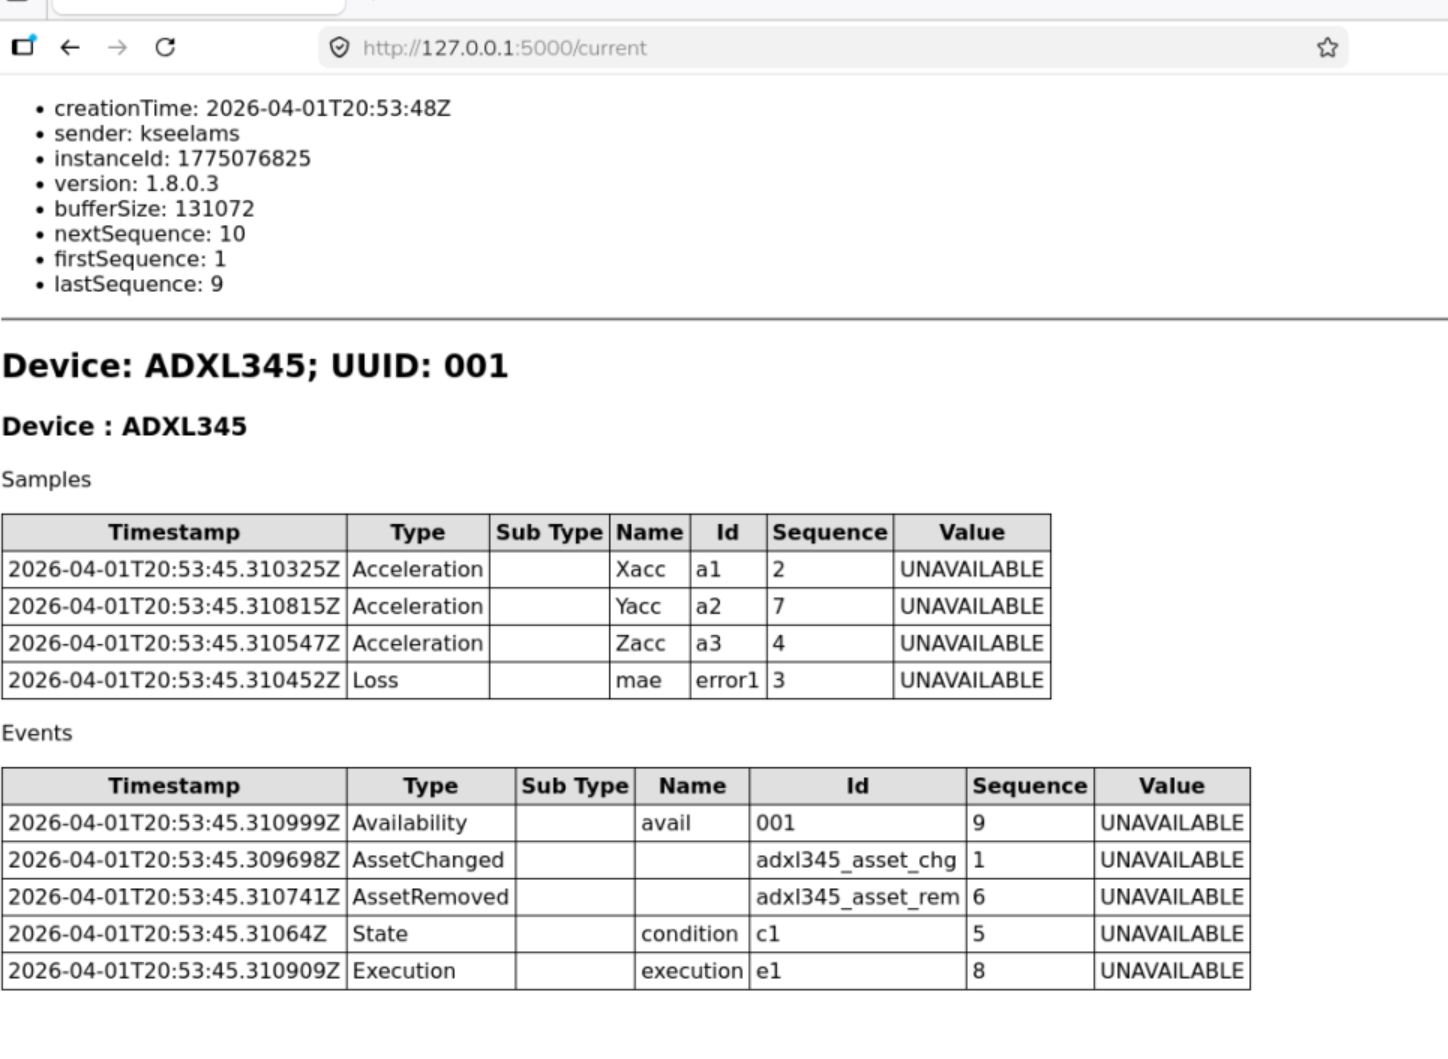

---

<br>

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig10.png?raw=true" width="70%">

*Figure 10 MTConnect agent ‘/current’ response without MTConnect adapter*

The next is to run MTConnect adapter. The sample MTConnect adapter based on the previous section is prepared, [lab9_adapter_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/lab9_code/lab9_adapter_sample.py?raw=true). The sample is incomplete as is. **Please note that to run MTConnect adapter in this case, ‘data_item.py’ and ‘mtconnect_adapter.py’ modules as the previous labs. In addition, the ‘/models’ and sub-directory for your autoencoder model must be in the same directory of the MTConnect adapter Python script**. Perform Task 3.2 to finish MTConnect data stream.

### Task 3.2

Complete the sample script ([lab9_adapter_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/lab9_code/lab9_adapter_sample.py?raw=true)) and then run MTConnect adapter.

  * You need to modify the variables wrapped in asteriks below. Also, you need to change the '???' parameters to the appropriate parameters.

  * If you have a different XML structure and data items from the example, you must change other parts of the sample script as well.


---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python3 ("Main of [lab9_adapter_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/lab9_code/lab9_adapter_sample.py?raw=true))**

```
if __name__ == "__main__":
    *model_path* = "models/YourModelDirectory/" # model file directory, you must change this!
    *model* = tf.keras.models.load_model(model_path) # load the model from the path above
    *threshold* =  # float: threshold (MAE loss) for the ML model
    *min_val* =  # float: minimum value for normalization
    *max_val* =  # float: maximum value for normalization
    
    # start MTConnect Adapter
    MTConnectAdapter(???, ???) # Args: host ip, port number
```

---


---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python3 (Part of "MTConnectAdapter" class of [lab9_adapter_sample.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/lab9_code/lab9_adapter_sample.py?raw=true))**

```
    def adapter_stream(self):
        while True:
            try:
                x, y, z = measureData(acc,1000) # x=x-axis, y=y-axis, z-axis acceleration array
                *input_feature* = # your input feature
                input_feature_normalized = tensorNormalization(input_feature, ???, ???) # normalized input feature
                result = predict(model, *FINAL_FEATURE_INPUT*, threshold)
                x_rms = timeFeatures(x)[2] # calculate rms of x-axis
                *y_rms* =  # calculate rms of y-axis
                *z_rms* =  # calculate rms of z-axis
                mae = result[?] # mean absolute error (loss) of the model
                
                if *AFF is running*:
                    execution = 'ACTIVE'
                    if *AFF is normal*:
                        condition = 'NORMAL'
                    else:
                        condition = 'ABNORMAL'
                else:
                    execution = 'STOPPED'
                    condition = 'UNAVAILABLE'

                now = datetime.datetime.now() # get current data time
                
                self.adapter.begin_gather() # start to collection
                
                self.Xacc.set_value(str(???))
                self.Yacc.set_value(str(???))
                self.Zacc.set_value(str(???))
                self.execution.set_value(str(???))
                self.condition.set_value(str(???))
                self.mae.set_value(str(???))
                
                self.adapter.complete_gather() # end of collection

```

---


### Task 3.3

Capture ‘/current’ response from the MTConnect agent as Figure 11 and attach it to the report.

  * Confirm if every data item works as expected by running the AFF.

---

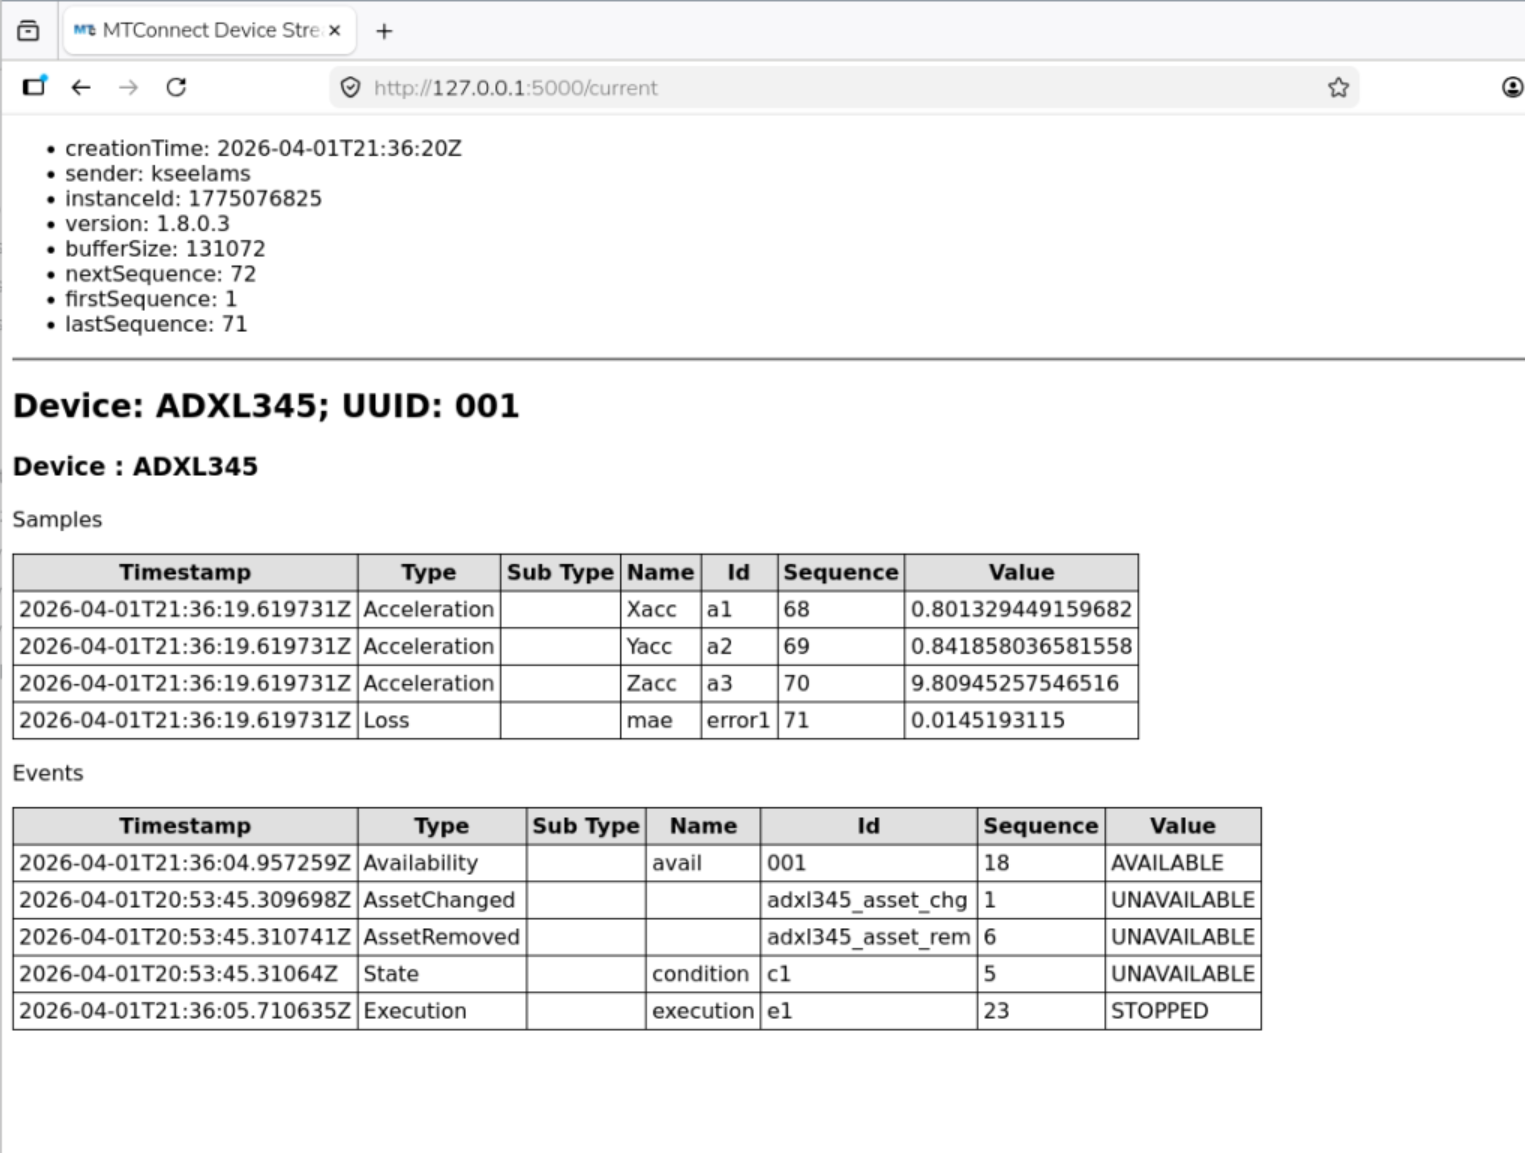

---


<br>

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab9_fig11.png?raw=true" width="70%">

*Figure 11 MTConnect agent ‘/current’ response with MTConnect adapter*


<br></br>

Please continue to [Lab 9.4 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab9/L9_Colab4.ipynb).